# Ridge and Lasso Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load and Preview Dataset

In [ ]:
df = pd.read_csv('student_performance_ridge_lasso.csv')
df = df.drop('Noise_Feature', axis=1)
df.head()

,Study_Hours,Sleep_Hours,Correlated_Feature,Exam_Score
0,4.370861,1.125717,2.231002,25.458869
1,9.556429,3.545642,4.126614,56.387584
2,7.587945,2.257424,5.937917,47.637358
3,6.387926,3.034283,3.827882,40.601308
4,2.404168,4.630266,-0.823059,23.435145


# Train-Test Split

In [ ]:
# Separate features (X) and target (y)
X = df.drop(['Exam_Score'], axis=1)
y = df['Exam_Score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(80, 3) (20, 3)


# Train and Evaluate Linear Regression Model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred = lin_reg.predict(X_test_scaled)

# 7. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 3.0220337789320477
R² Score: 0.9856750755587198


# Visualizing Linear Regression

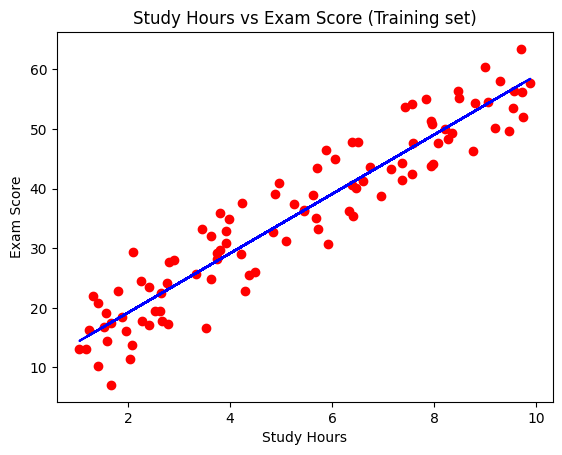

In [ ]:
df = pd.read_csv("student_performance_ridge_lasso.csv")
df = df.drop('Noise_Feature', axis=1)
# 2. Select one feature (Study_Hours) and target
X = df[['Study_Hours']]
y = df['Exam_Score']

# 3. Train Linear Regression
regressor = LinearRegression()
regressor.fit(X, y)

# 4. Plot scatter points and regression line
plt.scatter(X, y, color='red')  # Actual data points
plt.plot(X, regressor.predict(X), color='blue')  # Regression line

# 5. Labels and title
plt.title('Study Hours vs Exam Score (Training set)')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

# 6. Show plot
plt.show()

# Ridge Regression Model

In [ ]:
# Create a Ridge regression model
ridge = Ridge(alpha=1.5)  # You can adjust the alpha parameter
# Fit the model to the training data
ridge.fit(X_train, y_train)

# Predict on the test data
y_pred_ridge = ridge.predict(X_test)

# Predict on the test data
y_pred_ridge = ridge.predict(X_test)

print("\n----- Ridge Regression -----")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

rmse = np.sqrt(mse)

print("R²:", r2_score(y_test, y_pred_ridge))


----- Ridge Regression -----
MSE: 2.97004539109427
R²: 0.9859215088490397


# Lasso Regression Model

In [ ]:
# Create a Lasso regression model
lasso = Lasso(alpha=1.5)  # You can adjust the alpha parameter

# Fit the model to the training data
lasso.fit(X_train, y_train)

# Predict on the test data
y_pred_lasso = lasso.predict(X_test)

# Evaluate performance on the test set
print("\n----- Lasso Regression -----")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))

rmse = np.sqrt(mse)

print("R²:", r2_score(y_test, y_pred_lasso))


----- Lasso Regression -----
MSE: 3.5777967989036994
R²: 0.9830406697741607


# Ridge vs Lasso Regression Visualization

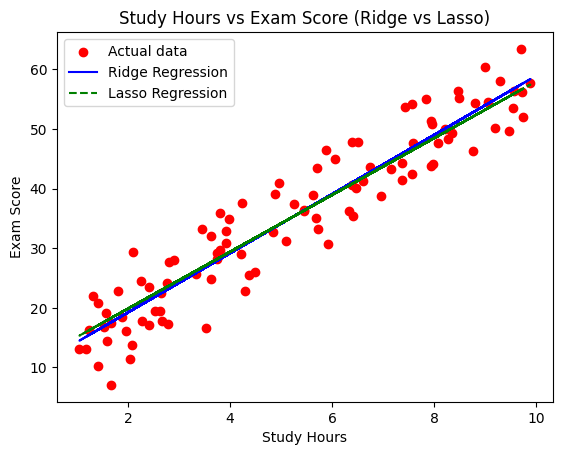

In [ ]:
X = df[['Study_Hours']]
y = df['Exam_Score']

# 3. Train Ridge Regression
ridge = Ridge(alpha=1.5)
ridge.fit(X, y)

# 4. Train Lasso Regression
lasso = Lasso(alpha=1.5)
lasso.fit(X, y)

# 5. Plot actual points
plt.scatter(X, y, color='red', label='Actual data')

# # 6. Plot Ridge regression line
plt.plot(X, ridge.predict(X), color='blue', label='Ridge Regression')

# 7. Plot Lasso regression line
plt.plot(X, lasso.predict(X), color='green', linestyle='--', label='Lasso Regression')

# 8. Labels and legend
plt.title('Study Hours vs Exam Score (Ridge vs Lasso)')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()

# 9. Show plot
plt.show()

# Linear vs Ridge Regression Visualization

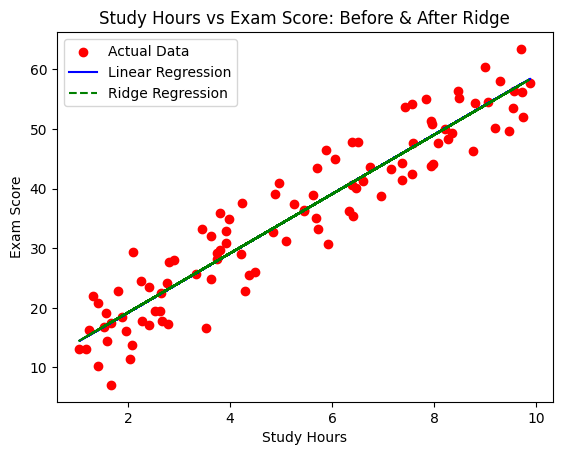

In [ ]:
# Features and target
X = df[['Study_Hours']]
y = df['Exam_Score']

# 1. Train old model (Linear Regression)
linear_reg = LinearRegression()
linear_reg.fit(X, y)

# 2. Train new model (Ridge Regression)
ridge_reg = Ridge(alpha=1.5)
ridge_reg.fit(X, y)

# 3. Plot actual data points
plt.scatter(X, y, color='red', label='Actual Data')

# 4. Plot old regression line
plt.plot(X, linear_reg.predict(X), color='blue', label='Linear Regression')

# 5. Plot new regression line
plt.plot(X, ridge_reg.predict(X), color='green', linestyle='--', label='Ridge Regression')

# 6. Labels, title, legend
plt.title('Study Hours vs Exam Score: Before & After Ridge')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()

# 7. Show plot
plt.show()

# Linear vs Lasso Regression Visualization

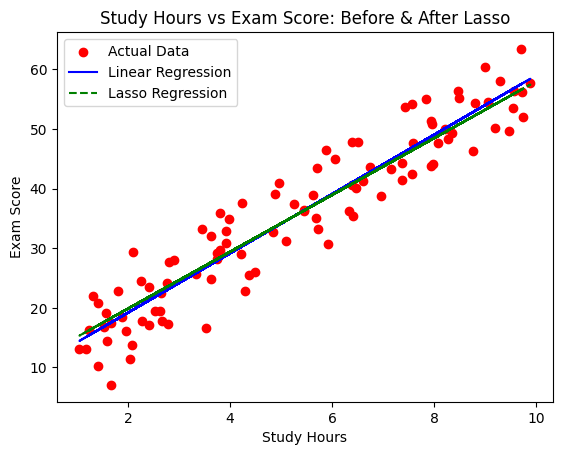

In [ ]:
X = df[['Study_Hours']]
y = df['Exam_Score']

# 3. Train old model (Linear Regression)
linear_reg = LinearRegression()
linear_reg.fit(X, y)

# 4. Train new model (Lasso Regression)
lasso_reg = Lasso(alpha=1.5)
lasso_reg.fit(X, y)

# 5. Plot actual data points
plt.scatter(X, y, color='red', label='Actual Data')

# 6. Plot old regression line
plt.plot(X, linear_reg.predict(X), color='blue', label='Linear Regression')

# 7. Plot new regression line
plt.plot(X, lasso_reg.predict(X), color='green', linestyle='--', label='Lasso Regression ')

# 8. Labels, title, legend
plt.title('Study Hours vs Exam Score: Before & After Lasso')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()

# 9. Show plot
plt.show()

**Conclusion**

Ridge and Lasso regression improve linear models by reducing overfitting. Ridge shrinks coefficients, while Lasso can also remove irrelevant features. Both help make predictions more stable and reliable compared to simple linear regression.